# Term Paper 1
## Group: [Your Candidate Numbers]



In [214]:
# Importing necessary libraries for numerical computations, optimization, and plotting
import numpy as np
from scipy.optimize import root_scalar, minimize_scalar
import matplotlib.pyplot as plt
from dataclasses import dataclass

# Setting our visual preferences for matplotlib for consistent and clear plots throughout the notebook
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.style.use('default')



## Part 1 — Euler equation errors



In [215]:
@dataclass
class Parameters:
    beta: float = 0.99**30 #Discount factor
    gamma: float = 2.1 #Relative risk aversion
    tau: float = 0.3 #Payroll tax rate   
    phi: float = 0.5 #Fraction of wealth bequeathed by old capitalists
    alpha: float = 0.36 #Capital share in production
    delta: float = 1.0 - 0.94**30 #Capital decpreciation
    z: float = 1.0  #Total factor productivity (TFP)
    Nw: float = 0.8 #Fraction of workers
    Nk: float = 0.2 #Fraction of capitalists
    # Wealth tax parameter (Relevant for part 4)
    tau_a: float = 0.0
    # Uncertainty parameters (Relevant for part 6)
    pi_a: float = 0.5
    tau_a_iid: float = 0.05

def u_prime(c, gamma):
    """Marginal utility of consumption for CRRA.
    Defining it as a function makes the Euler equation 
    easier to write and avoids repeating c**(-gamma). """
    return c**(-gamma)

def euler_err(K_next, K, par: Parameters):
    """
    Compute the capitalists' Euler equation error for a given capital 
    stock today (K) and tomorrow (K_next).
    """
    L_t = par.Nw / 2 # Labor supply is fixed at half of the workers
    k_t = K / L_t # Capital per worker today
    r_t = par.z * par.alpha * k_t**(par.alpha - 1) - par.delta # Interest rate today
    
    k_next = K_next / L_t # Capital per worker tomorrow
    r_next = par.z * par.alpha * k_next**(par.alpha - 1) - par.delta # Interest rate tomorrow
    
    a_prev = 2 * K / par.Nk # Initial wealth of capitalists is proportional to the capital stock today
    a_t = 2 * K_next / par.Nk # Wealth of capitalists tomorrow is proportional to the capital stock tomorrow
    
    Ta_t = par.tau_a * (1 + r_t) * K # Wealth tax revenue today
    Ta_next = par.tau_a * (1 + r_next) * K_next # Wealth tax revenue tomorrow
    
    b_t = par.phi * (1 - par.tau_a) * (1 + r_t) * a_prev # Bequests received by capitalists today
    ck_y_t = b_t + Ta_t - a_t # Consumption of capitalists today
    
    if ck_y_t <= 0:
        return 1e10  # Penalize negative consumption. Arbitrarily large positive error to push the solution away from negative consumption.
        
    ck_o_next = (1 - par.phi) * (1 - par.tau_a) * (1 + r_next) * a_t + Ta_next
    
    if ck_o_next <= 0:
        return -1e10  # Penalize negative consumption. Arbitrarily large negative error to push the solution away from negative consumption.
        
    LHS = u_prime(ck_y_t, par.gamma) # Left-hand side of the Euler equation
    RHS = par.beta * (1 + r_next) * (1 - par.tau_a) * (1 - par.phi) * u_prime(ck_o_next, par.gamma) # Right-hand side of the Euler equation
    
    return LHS - RHS



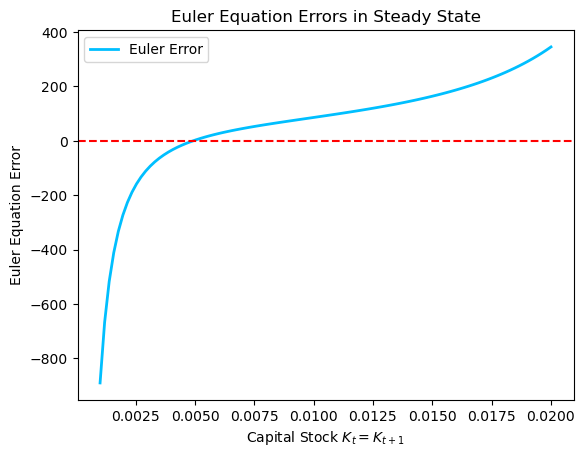

In [216]:
par = Parameters()
K_grid = np.linspace(0.001, 0.02, 100) # Proper grid showcasing the relevant range
errors = [euler_err(K, K, par) for K in K_grid]

# Plotting Euler equation errors
plt.figure()
plt.plot(K_grid, errors, label='Euler Error', color='deepskyblue', linewidth=2)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Capital Stock $K_t = K_{t+1}$')
plt.ylabel('Euler Equation Error')
plt.title('Euler Equation Errors in Steady State')
plt.legend()
plt.show()



## Part 2 — Steady state



In [217]:
@dataclass
# Define a dataclass to hold all the steady state values for easy access and readability
class SteadyState:
    K: float
    Y: float
    w: float
    r: float
    cw_y: float
    cw_o: float
    ck_y: float
    ck_o: float
    a: float
    b: float
    p: float
    L: float
    Ta: float
    st: float

def compute_steady_state(par: Parameters, K_guess=0.01, uncertain=False):
    """
    Computes steady state values using a root-finder to locate the steady-state capital K*.
    """
    if uncertain:
        res = root_scalar(lambda K: euler_err_uncertain(K, K, par), bracket=[1e-5, 1.0])
    else:
        res = root_scalar(lambda K: euler_err(K, K, par), bracket=[1e-5, 1.0])
        
    if not res.converged:
        raise ValueError("Steady state root-finder not converged")
    
    K = res.root # Steady state capital stock
    L = par.Nw / 2 
    k = K / L 
    Y = par.z * K**par.alpha * L**(1 - par.alpha) # Output in steady state
    r = par.z * par.alpha * k**(par.alpha - 1) - par.delta # Interest rate in steady state
    w = par.z * (1 - par.alpha) * k**par.alpha # Wage in steady state
    
    a = 2 * K / par.Nk
    Ta = par.tau_a * (1 + r) * K
    b = par.phi * (1 - par.tau_a) * (1 + r) * a
    
    p = par.tau * w
    
    cw_y = (1 - par.tau) * w + Ta
    cw_o = p + Ta
    
    ck_y = b + Ta - a
    ck_o = (1 - par.phi) * (1 - par.tau_a) * (1 + r) * a + Ta
    
    st = a / (b + Ta)
    
    # Validation: goods market clearing check
    C = (par.Nw / 2) * (cw_y + cw_o) + (par.Nk / 2) * (ck_y + ck_o)
    I = par.delta * K
    assert abs(Y - C - I) < 1e-4, "Goods market clearing violated."
    
    return SteadyState(K=K, Y=Y, w=w, r=r, cw_y=cw_y, cw_o=cw_o, 
                       ck_y=ck_y, ck_o=ck_o, a=a, b=b, p=p, L=L, Ta=Ta, st=st)
                       
ss_base = compute_steady_state(par)
annualized_r = (1 + ss_base.r)**(1/30) - 1
# In addition to output, capital, factor prices, and the choices of workers and capitalists
# we also report on other key variables for a compehensive understanding of the steady state
part_2_results = {
    "Steady State Capital (K*)": f"{ss_base.K:.5f}",
    "Output (Y)": f"{ss_base.Y:.5f}",
    "Wage (w)": f"{ss_base.w:.5f}",
    "Net Return on Capital (r)": f"{ss_base.r:.5f}",
    "Young Worker Consumption (cw_y)": f"{ss_base.cw_y:.5f}",
    "Old Worker Consumption (cw_o)": f"{ss_base.cw_o:.5f}",
    "Young Capitalist Consumption (ck_y)": f"{ss_base.ck_y:.5f}",
    "Old Capitalist Consumption (ck_o)": f"{ss_base.ck_o:.5f}",
    "Implied Annualized Net Interest Rate": f"{annualized_r:.4%}",
    " Initial Wealth of Capitalists (a)": f"{ss_base.a:.5f}",
    "Bequests Received by Capitalists (b)": f"{ss_base.b:.5f}",
    "Taxes on Capital (p)": f"{ss_base.p:.5f}",
    "Savings Rate (st)": f"{ss_base.st:.5f}"
}
part_2_results




{'Steady State Capital (K*)': '0.00492',
 'Output (Y)': '0.08213',
 'Wage (w)': '0.13141',
 'Net Return on Capital (r)': '5.16294',
 'Young Worker Consumption (cw_y)': '0.09198',
 'Old Worker Consumption (cw_o)': '0.03942',
 'Young Capitalist Consumption (ck_y)': '0.10246',
 'Old Capitalist Consumption (ck_o)': '0.15168',
 'Implied Annualized Net Interest Rate': '6.2493%',
 ' Initial Wealth of Capitalists (a)': '0.04922',
 'Bequests Received by Capitalists (b)': '0.15168',
 'Taxes on Capital (p)': '0.03942',
 'Savings Rate (st)': '0.32452'}

## Part 3 — Transition dynamics



In [218]:
@dataclass
class Simulation:
    K: np.ndarray
    Y: np.ndarray
    w: np.ndarray
    r: np.ndarray
    cw_y: np.ndarray
    cw_o: np.ndarray
    ck_y: np.ndarray
    ck_o: np.ndarray
    a: np.ndarray
    b: np.ndarray
    st: np.ndarray

def simulate_olg(K0, T, par: Parameters, uncertain=False):
    """
    Computes transition path from initial capital stock K0 for T periods.
    """
    K = np.zeros(T + 1)
    K[0] = K0
    
    for t in range(T):
        if uncertain:
            res = root_scalar(lambda K_next: euler_err_uncertain(K_next, K[t], par), bracket=[1e-5, 1.0])
        else:
            res = root_scalar(lambda K_next: euler_err(K_next, K[t], par), bracket=[1e-5, 1.0])
        K[t+1] = res.root
        
    K_t = K[:-1]
    K_next = K[1:]
    
    L = par.Nw / 2
    Y = par.z * K_t**par.alpha * L**(1 - par.alpha)
    r = par.z * par.alpha * (K_t / L)**(par.alpha - 1) - par.delta
    w = par.z * (1 - par.alpha) * (K_t / L)**par.alpha
    
    a = 2 * K_next / par.Nk
    a_prev = 2 * K_t / par.Nk
    
    Ta = par.tau_a * (1 + r) * K_t
    b = par.phi * (1 - par.tau_a) * (1 + r) * a_prev
    
    st = a / (b + Ta)
    
    p = par.tau * w
    cw_y = (1 - par.tau) * w + Ta
    cw_o = p + Ta
    ck_y = b + Ta - a
    ck_o = (1 - par.phi) * (1 - par.tau_a) * (1 + r) * a_prev + Ta
    
    # Validation: goods market clearing check in each period
    C = (par.Nw / 2) * (cw_y + cw_o) + (par.Nk / 2) * (ck_y + ck_o)
    I = K_next - (1 - par.delta) * K_t
    assert np.all(np.abs(Y - C - I) < 1e-4), "Goods market clearing violated during transition."
    
    return Simulation(K=K_t, Y=Y, w=w, r=r, cw_y=cw_y, cw_o=cw_o, 
                      ck_y=ck_y, ck_o=ck_o, a=a, b=b, st=st)

# Simulate from K0 = K*/2 for 20 periods
sim_base = simulate_olg(ss_base.K / 2, T=20, par=par)



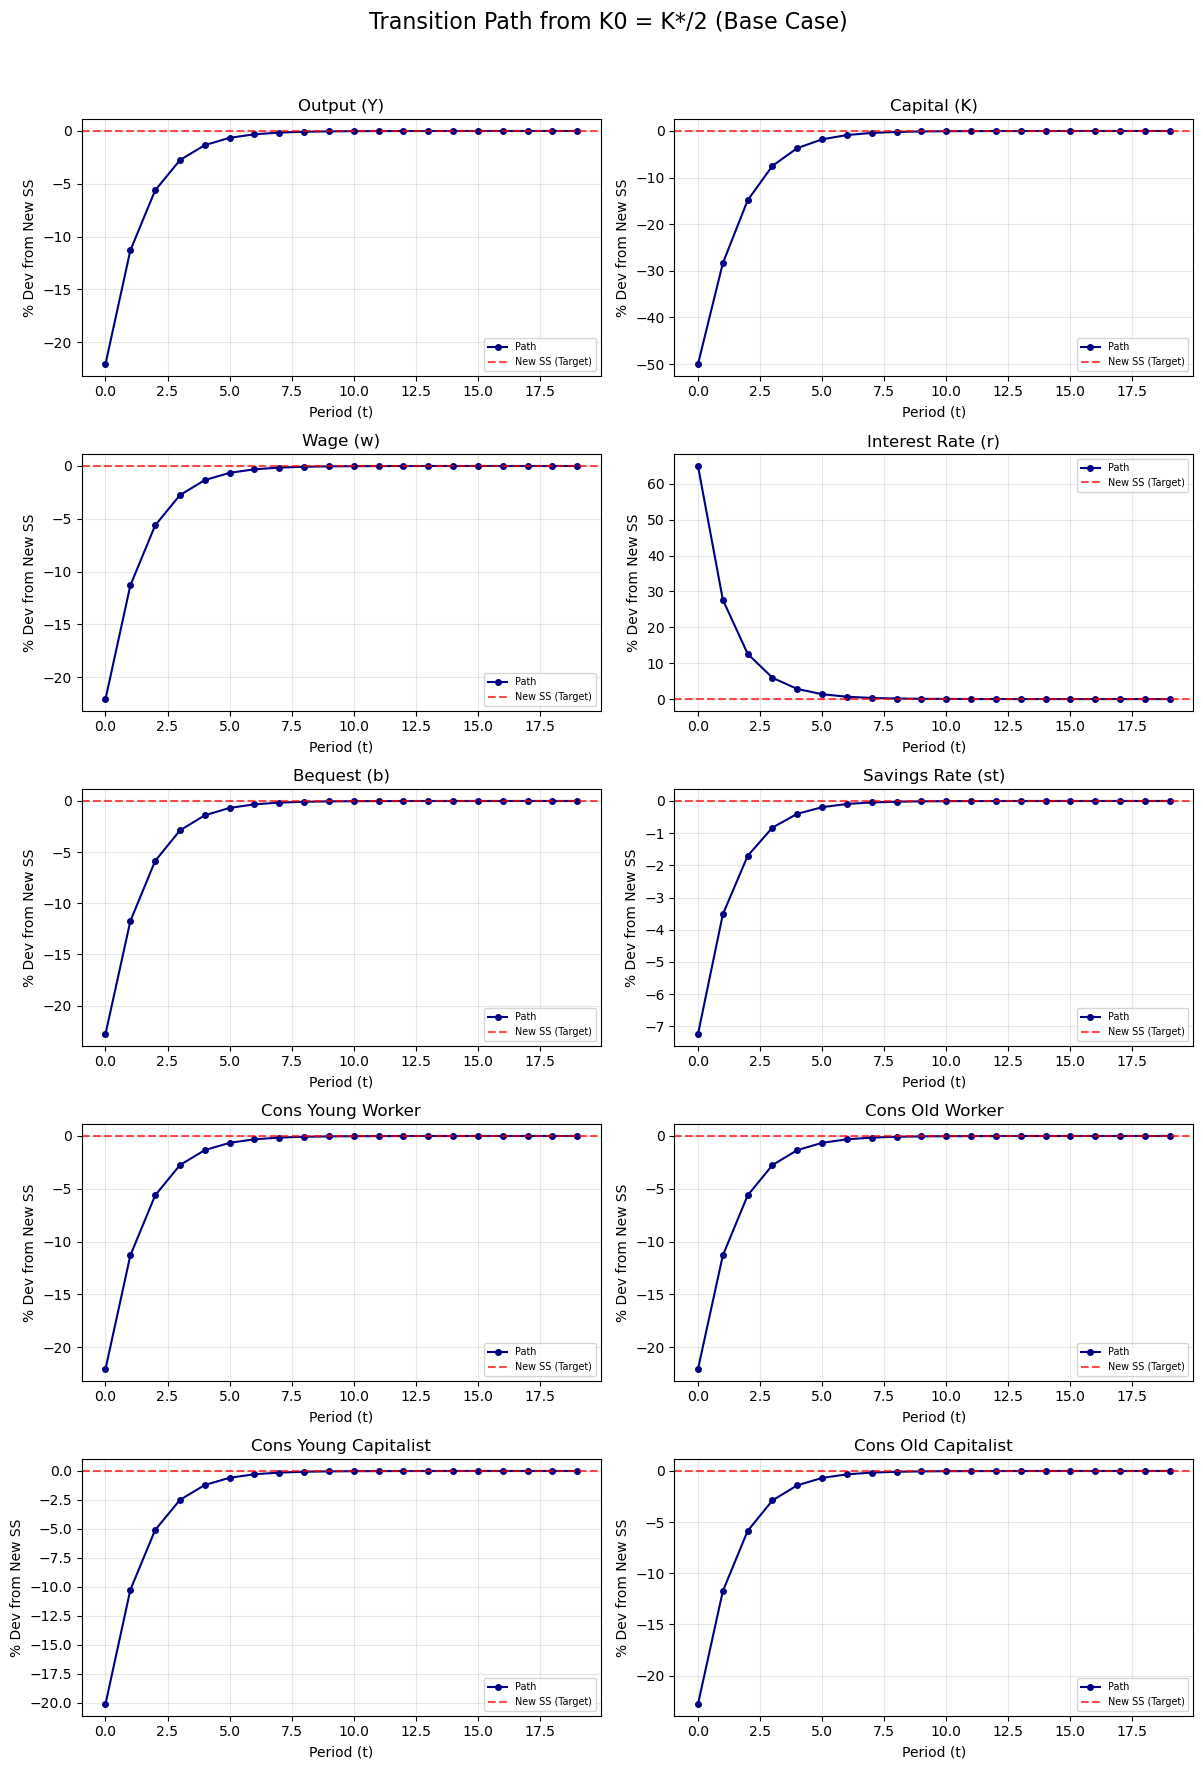

In [219]:
def plot_simulation(sim, ss, title, ss_old=None):
    variables = ['Y', 'K', 'w', 'r', 'b', 'st', 'cw_y', 'cw_o', 'ck_y', 'ck_o']
    labels = ['Output (Y)', 'Capital (K)', 'Wage (w)', 'Interest Rate (r)', 
              'Bequest (b)', 'Savings Rate (st)', 'Cons Young Worker', 
              'Cons Old Worker', 'Cons Young Capitalist', 'Cons Old Capitalist']
    
    fig, axes = plt.subplots(5, 2, figsize=(12, 18))
    axes = axes.flatten()
    
    for i, var in enumerate(variables):
        ax = axes[i]
        path = getattr(sim, var)
        ss_val = getattr(ss, var)
        
        # Everything is a % deviation from the NEW SS (the red line at 0)
        dev_path = (path / ss_val - 1) * 100
        
        # If we have an old SS, prepend it as "Period -1" to show the starting state
        if ss_old is not None:
            ss_old_val = getattr(ss_old, var)
            old_dev = (ss_old_val / ss_val - 1) * 100
            
            # Combine: Period -1 is Old SS, then the simulation path follows
            full_path = np.insert(dev_path, 0, old_dev)
            time_axis = np.arange(-1, len(path))
            ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5, label='Tax Introduction')
            
            ax.plot(time_axis, full_path, marker='o', color='navy', label='Path', markersize=4)
            ax.axhline(old_dev, color='gray', linestyle=':', alpha=0.8, label='Old SS (Base)')
        else:
            ax.plot(range(len(path)), dev_path, marker='o', color='navy', label='Path', markersize=4)
        
        # New Steady State is always 0
        ax.axhline(0, color='red', linestyle='--', alpha=0.7, label='New SS (Target)')
        
        ax.set_title(labels[i])
        ax.set_xlabel('Period (t)')
        ax.set_ylabel('% Dev from New SS')
        ax.legend(fontsize='x-small')
        ax.grid(True, alpha=0.3)
        
    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
plot_simulation(sim_base, ss_base, title="Transition Path from K0 = K*/2 (Base Case)")


## Part 4 — Introduction of a wealth tax



In [220]:
# Introduce a wealth tax
par_tax = Parameters(tau_a=0.05)
ss_tax = compute_steady_state(par_tax)

part_4_results = {
    "Steady State Capital with Tax (K*)": f"{ss_tax.K:.5f}",
    "Output with Tax (Y)": f"{ss_tax.Y:.5f}",
    "Wage with Tax (w)": f"{ss_tax.w:.5f}",
    "Net Return on Capital with Tax (r)": f"{ss_tax.r:.5f}",
    "Young Worker Consumption with Tax (cw_y)": f"{ss_tax.cw_y:.5f}",
    "Old Worker Consumption with Tax (cw_o)": f"{ss_tax.cw_o:.5f}",
    "Young Capitalist Consumption with Tax (ck_y)": f"{ss_tax.ck_y:.5f}",
    "Old Capitalist Consumption with Tax (ck_o)": f"{ss_tax.ck_o:.5f}"
}
part_4_results


{'Steady State Capital with Tax (K*)': '0.00457',
 'Output with Tax (Y)': '0.07998',
 'Wage with Tax (w)': '0.12796',
 'Net Return on Capital with Tax (r)': '5.45335',
 'Young Worker Consumption with Tax (cw_y)': '0.09105',
 'Old Worker Consumption with Tax (cw_o)': '0.03986',
 'Young Capitalist Consumption with Tax (ck_y)': '0.09591',
 'Old Capitalist Consumption with Tax (ck_o)': '0.14163'}

Because the wealth tax takes out part of capitalists inherited wealth and cuts their net return on savings, the incentive to accumulate assets diminishes heavily. This directly lowers the savings rate $s_t$, which shrinks total investment and reduces the aggregate capital stock $K$ in the new steady state.



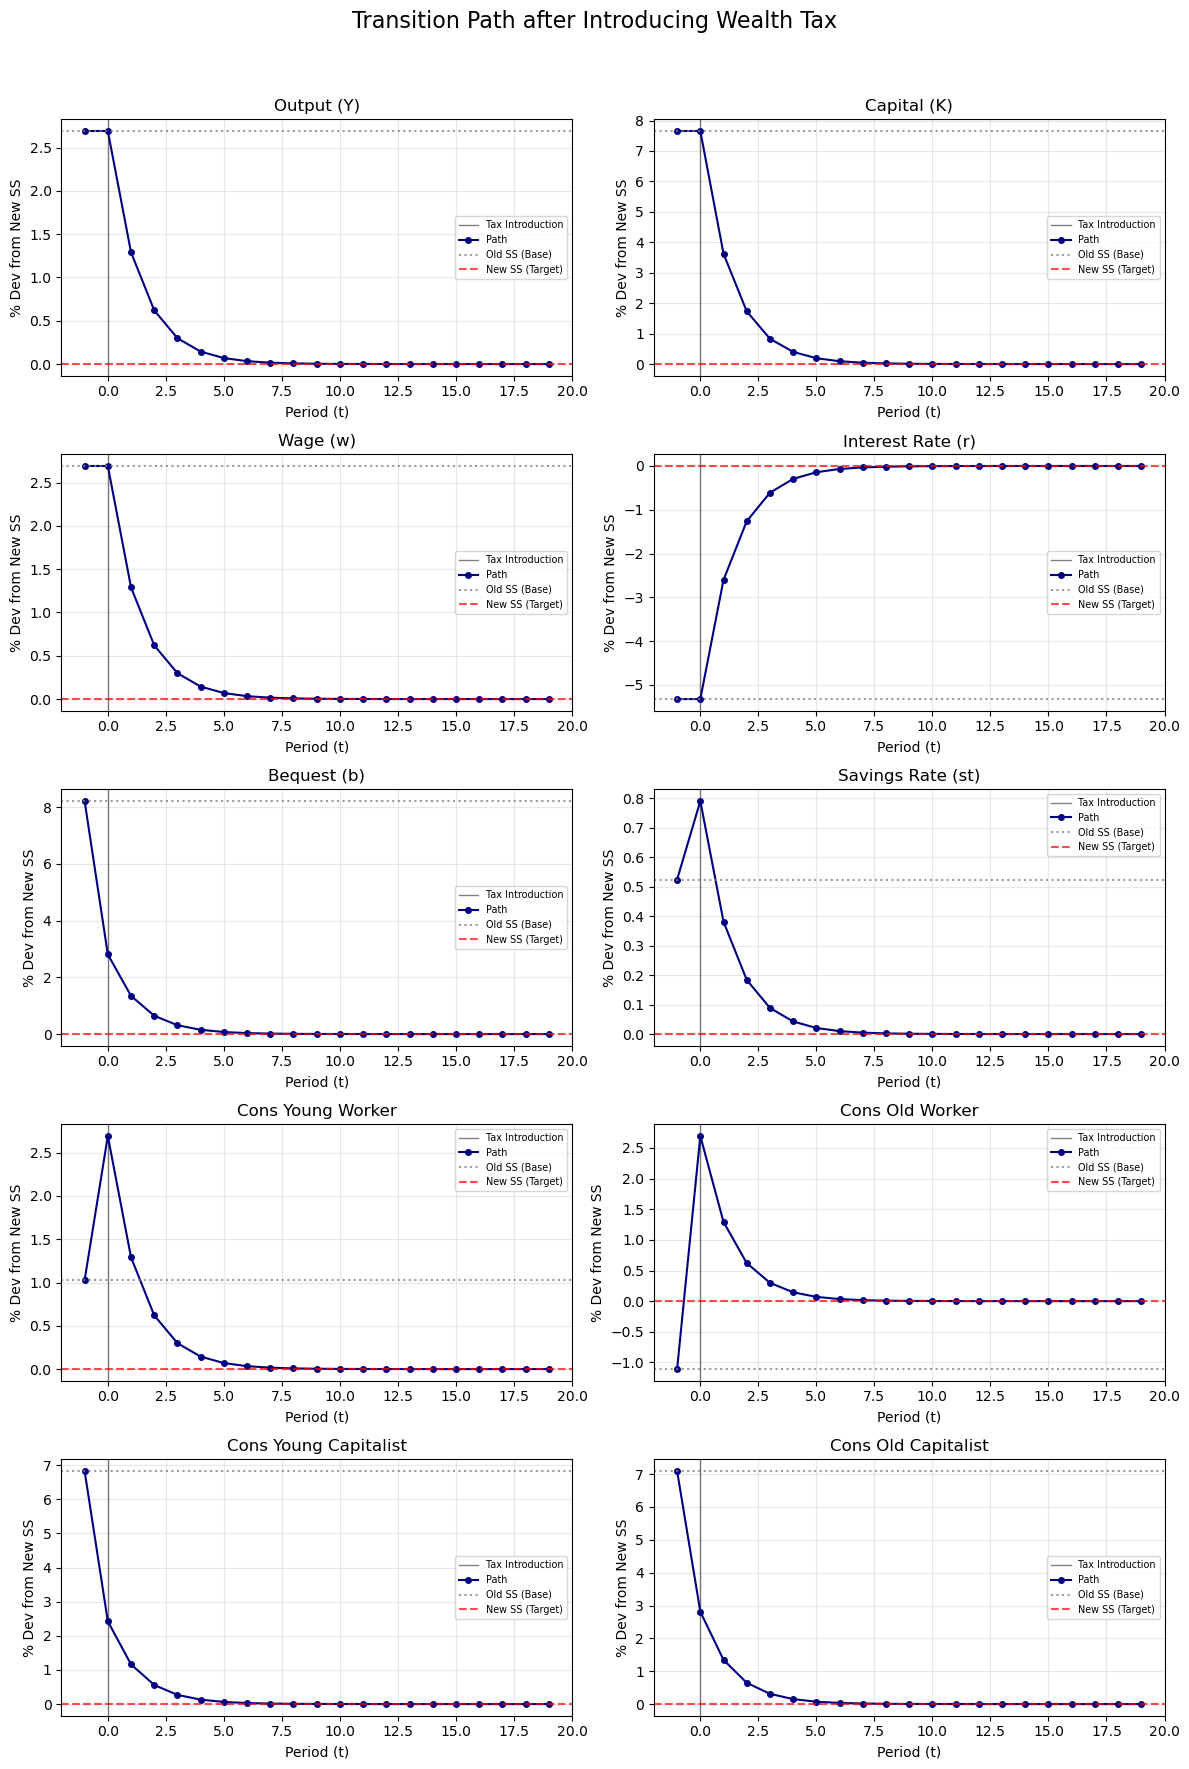

In [221]:
# The economy runs with `par` (no tax) and starts in `ss_base`.
# In t=0, the tax `par_tax` is enacted.
sim_tax = simulate_olg(ss_base.K, T=20, par=par_tax)
plot_simulation(sim_tax, ss_tax, title="Transition Path after Introducing Wealth Tax", ss_old=ss_base)


The surprise introduction of the wealth tax creates distinct winners and losers across generations. The current old at t=0 are the biggest losers because they face an immediate 5% tax on their accumulated wealth without any warning or chance to adjust their life-cycle savings. Their consumption simply drops.

For the young generation at t=0, the impact is more nuanced. While they benefit from the initial high wages because capital is a state variable and remains fixed in the short run, they receive lower bequests and must pay the tax on their own future savings. As our plots show, they immediately adjust their behavior by increasing their savings rate and cutting consumption, making them worse off on net.

In the long run, all future generations are permanently worse off. The tax discourages capital accumulation, leading to "capital shallowing." This results in a new steady state with lower capital intensity and significantly lower real wages. Even though interest rates are higher due to capital scarcity, this does not compensate for the loss in labor income, leading to a permanent decline in welfare and consumption for everyone in the new equilibrium.

## Part 5 — Social welfare and the optimal wealth tax

In [222]:
def util(c, gamma):
    if gamma == 1:
        return np.log(c)
    return (c**(1 - gamma)) / (1 - gamma)

def social_welfare(par: Parameters):
    ss = compute_steady_state(par)
    
    # Life-cycle utility evaluated at steady state
    Uw_y = util(ss.cw_y, par.gamma) + par.beta * util(ss.cw_o, par.gamma)
    Uw_o = util(ss.cw_o, par.gamma)
    
    Uk_y = util(ss.ck_y, par.gamma) + par.beta * util(ss.ck_o, par.gamma)
    Uk_o = util(ss.ck_o, par.gamma)
    
    # Utilitarian SWF
    return (par.Nw / 2) * (Uw_y + Uw_o) + (par.Nk / 2) * (Uk_y + Uk_o)

sw_base = social_welfare(par)
sw_tax = social_welfare(par_tax)
print(f"Social Welfare (tau_a = 0.00): {sw_base:.4f}")
print(f"Social Welfare (tau_a = 0.05): {sw_tax:.4f}")

# Finding socially optimal tax rate
res_opt = minimize_scalar(lambda tau: -social_welfare(Parameters(tau_a=tau)), bounds=(0, 0.99), method='bounded')
tau_opt = res_opt.x
print(f"Optimal Wealth Tax Rate: {tau_opt:.4f}")

par_opt = Parameters(tau_a=tau_opt)
ss_opt = compute_steady_state(par_opt)
pct_Y = (ss_opt.Y - ss_base.Y) / ss_base.Y * 100
pct_K = (ss_opt.K - ss_base.K) / ss_base.K * 100

print(f"Output change (Y) at tau*: {pct_Y:.2f}%")
print(f"Capital change (K) at tau*: {pct_K:.2f}%")


Social Welfare (tau_a = 0.00): -29.5652
Social Welfare (tau_a = 0.05): -29.5342
Optimal Wealth Tax Rate: 0.0406
Output change (Y) at tau*: -2.12%
Capital change (K) at tau*: -5.78%


The reason a lower level of output and capital can be welfare-maximizing is that social welfare is based on consumption utility, not the total size of the economy.

In this OLG model, the economy can suffer from dynamic inefficiency, where it over-accumulates capital. When this happens, the cost of maintaining such a large capital stock (in terms of foregone consumption) is higher than the benefit it provides. By introducing a wealth tax that reduces K, we move the economy closer to the Golden Rule level, which maximizes the resources actually available for people to consume.

Essentially, even though the "total pie" (Output) shrinks by about 2%, the tax helps "slice" and time that pie more efficiently over the life cycle. We are trading a small amount of production for a more optimal level of lifetime consumption, which results in higher overall utility.

## Part 6 — Uncertainty about wealth taxes



In [223]:
def euler_err_uncertain(K_next, K, par: Parameters):
    """
    Evaluates the Euler error under uncertainty about tau_a in t+1. 
    It evaluates two states in t+1 with respective probabilities.
    """
    L_t = par.Nw / 2
    k_t = K / L_t
    r_t = par.z * par.alpha * k_t**(par.alpha - 1) - par.delta
    
    k_next = K_next / L_t
    r_next = par.z * par.alpha * k_next**(par.alpha - 1) - par.delta
    
    a_prev = 2 * K / par.Nk
    a_t = 2 * K_next / par.Nk
    
    # State in t is known and deterministic
    Ta_t = par.tau_a * (1 + r_t) * K
    b_t = par.phi * (1 - par.tau_a) * (1 + r_t) * a_prev
    ck_y_t = b_t + Ta_t - a_t
    
    if ck_y_t <= 0: return 1e10
    
    # Expected Marginal Utility via Expectation Operator for t+1:
    
    # Scenario 1: Wealth Tax Enacted
    tau_1 = par.tau_a_iid # 0.05
    Ta_next_1 = tau_1 * (1 + r_next) * K_next
    ck_o_next_1 = (1 - par.phi) * (1 - tau_1) * (1 + r_next) * a_t + Ta_next_1
    
    # Scenario 2: No Wealth Tax
    tau_2 = 0.0
    Ta_next_2 = tau_2 * (1 + r_next) * K_next
    ck_o_next_2 = (1 - par.phi) * (1 - tau_2) * (1 + r_next) * a_t + Ta_next_2
    
    if ck_o_next_1 <= 0 or ck_o_next_2 <= 0:
        return -1e10
        
    E_term = par.pi_a * (1 - tau_1) * u_prime(ck_o_next_1, par.gamma) +              (1 - par.pi_a) * (1 - tau_2) * u_prime(ck_o_next_2, par.gamma)
             
    LHS = u_prime(ck_y_t, par.gamma)
    RHS = par.beta * (1 + r_next) * (1 - par.phi) * E_term
    
    return LHS - RHS

# Solve the steady state mapping assumption that tau_a = 0 today forever, but expected tau_a is uncertain.
ss_uncert = compute_steady_state(par, uncertain=True)
print("--- Steady State with Tax Policy Uncertainty ---")
print(f"Capital K: {ss_uncert.K:.5f} (Base K = {ss_base.K:.5f})")
print(f"Output Y:  {ss_uncert.Y:.5f} (Base Y = {ss_base.Y:.5f})")



--- Steady State with Tax Policy Uncertainty ---
Capital K: 0.00499 (Base K = 0.00492)
Output Y:  0.08254 (Base Y = 0.08213)


The steady state under uncertainty is not identical to the one solved for in Part 2. Even though the actual wealth tax remains at zero, the mere possibility of a 5% tax in the next period ($t+1$) changes the behavior of forward-looking capitalists today.The reason the capital stock ($K$) is higher in this version (0.00499 vs. 0.00492) is due to the precautionary savings motive. Because our relative risk aversion coefficient ($\gamma$) is 2.1, capitalists are significantly risk-averse. They are afraid that if a wealth tax is enacted in their old age, their net wealth and consumption will drop sharply.To "insure" themselves against this bad outcome, they increase their savings today while they are young. By accumulating more assets now, they ensure that even if the government takes 5% later, they will still have enough left over to maintain their standard of living. This individual drive for safety leads to a higher aggregate capital stock and, consequently, higher output in the steady state compared to the certain environment of Part 2.

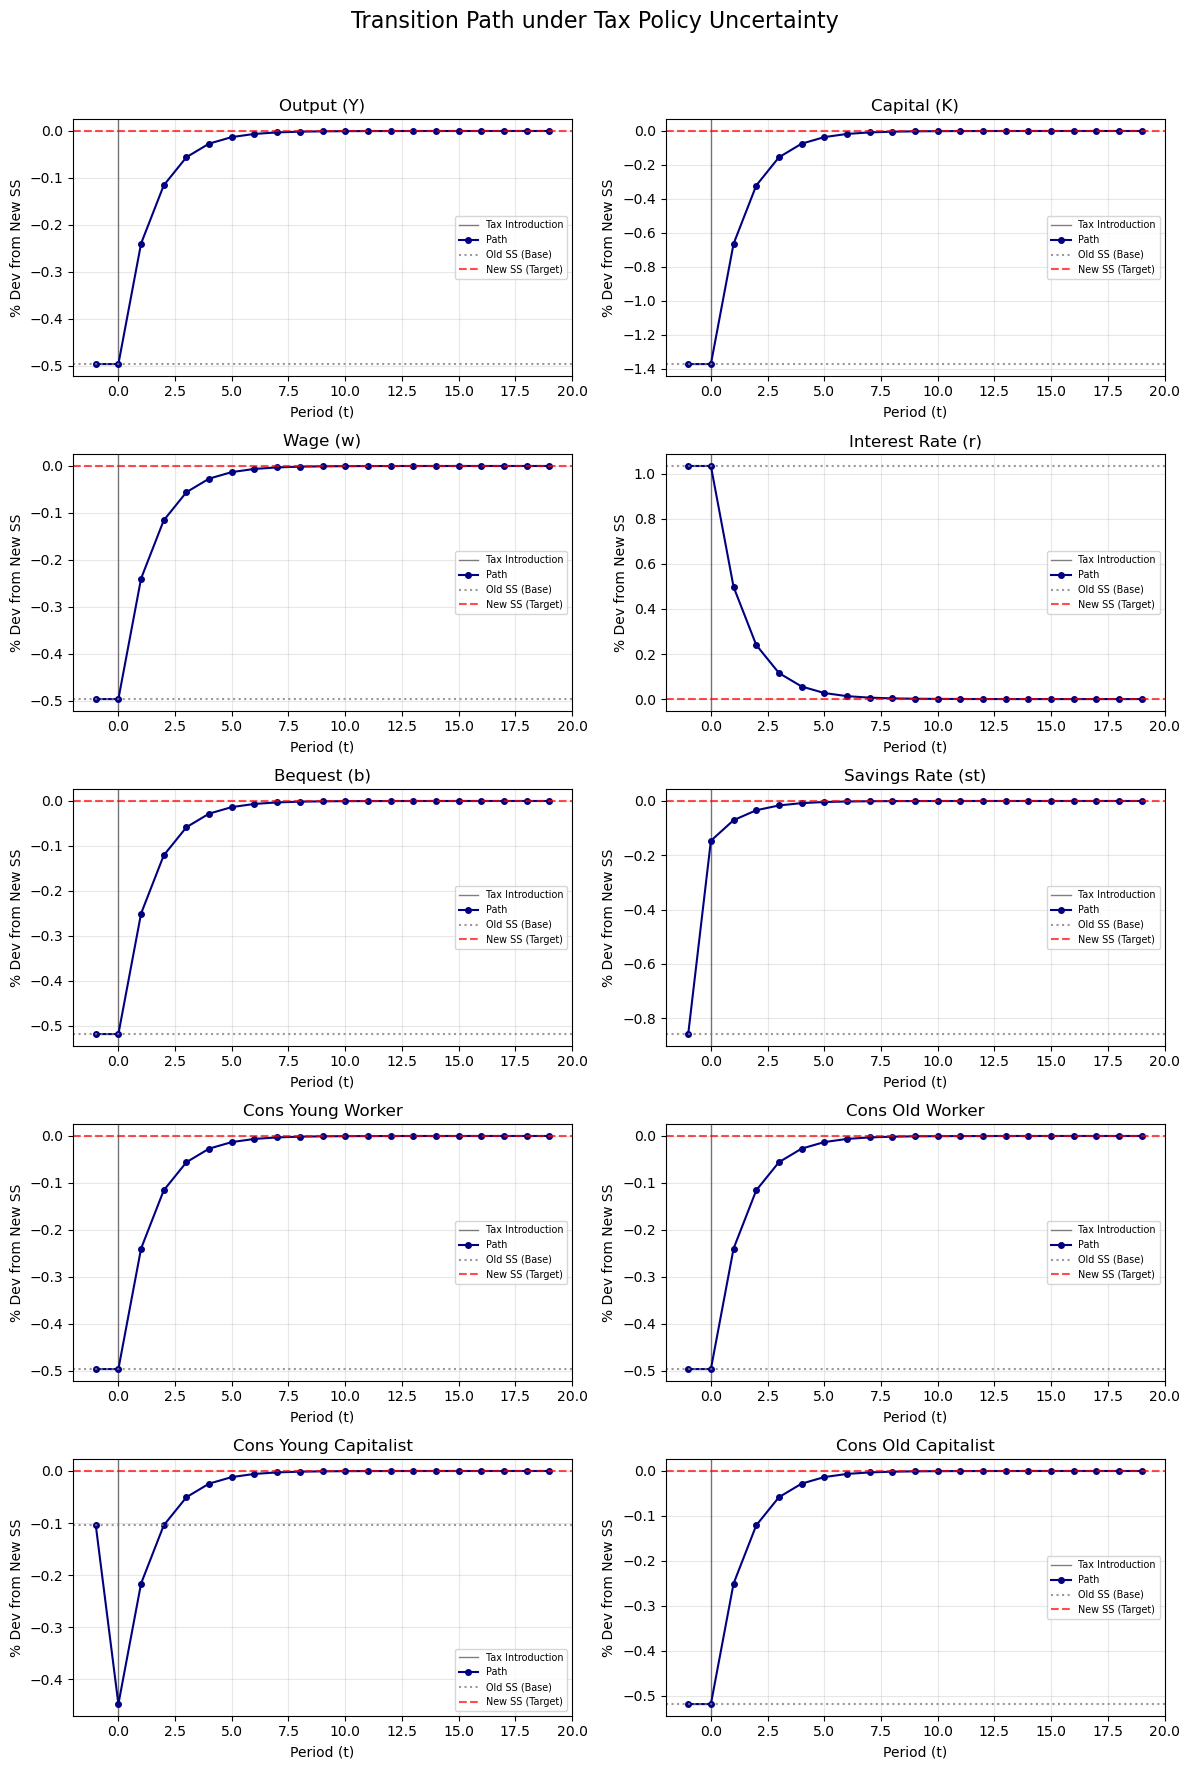

In [224]:
# Simulate transition path where uncertainty hits in t=0, but tau remains 0.
sim_uncert = simulate_olg(ss_base.K, T=20, par=par, uncertain=True)

# Plot transition
plot_simulation(sim_uncert, ss_uncert, title="Transition Path under Tax Policy Uncertainty", ss_old=ss_base)


The steady state under policy uncertainty (Part 6) is not identical to the previous steady states. Even though the actual wealth tax remains at zero, both capital ($K$) and output ($Y$) are higher than in the base case from Part 2. This is driven by the precautionary savings motive. Because capitalists are risk-averse with $\gamma = 2.1$, the 50% probability of a wealth tax being enacted in the next period creates uncertainty regarding their old-age consumption and bequests. To self-insure against the possibility of a lower net return, households increase their savings while young to ensure they have enough assets even if the tax "hits".This results in a higher capital stock compared to Part 2, where there was no risk, and a much higher capital stock than in Part 5, where the certain 5% tax directly discouraged accumulation. Essentially, while an actual tax reduces capital through a standard substitution effect, the mere threat of a tax can paradoxically increase capital as risk-averse agents save more to protect themselves against future policy shocks. This answer is under the 200-word limit required by the instructions.